# TECH2 Mandatory assignment 2

## About the mandatory assignment

-   The assignment must be completed individually.
-   You are allowed to use all online resources for help, including generative AI. You must include a statement on how you used AI to solve the tasks.
-   After the assignment deadline, you must perform a peer review of two other students' assignment on Canvas. You're not allowed to use AI to write the peer-review for you.
-   Deadline for the assignment: Friday, October 17, 16:00.
-   Deadline for the peer review: Friday, October 24, 16:00.


## Requirements

-   Your solution needs to be uploaded to GitHub. You should fork the assignment repository at
    [https://github.com/richardfoltyn/TECH2-H25-assignment2](https://github.com/richardfoltyn/TECH2-H25-assignment2)
    and add your solution to this notebook.
-   All commits in your repository must be *prior* to the deadline. 
-   You need to make sure that your GitHub repository is publicly accessible. This can be changed in the GitHub repository setttings, if required.
-   You need to submit the URL to the your GitHub repository on Canvas.
-   Make sure your notebook runs without errors (`Restart` and `Run all`). 
-   Your notebook *must* run with the TECH2 environment we've been using in part 2. You can create this environment from the 
    `environment.yml` file in this repository if you haven't done so earlier.


## Tasks

In this assignment, you are asked to analyze a 10% sub-sample of the Survey of Consumer Finances (SCF), a survey of household portfolios that is representative of the US population. The survey was administered every 3 years from 1989 to 2022. The appendix in this document contains a description of the variables present in this data set (this is a subset; the original SCF contains many more variables).

1.  Data preprocessing

    1.  Read the CSV file `SCF_10pct.csv` stored in this repository.
    2.  Keep only observations where the household head is aged between 25 and 89. 
    3.  Create the column `'college'`, which contains an indicator variable that is 1 when the household head has at least some college (column `'educ'` is 3 or 4), and 0 otherwise.
    4.  Divide the values in the column `'networth'` by 1,000 so that they are reported in thousands of US dollars.
    5.  Report the number of observations in the final sample.

2.  In this part, you're asked to analyze how net worth (total gross assets minus total debt) varies across the four education levels (no high school, high school, some college, 4-year college or more):

    1.  Compute the average net worth (in thousands of US dollars) by education (use a loop).
    2.  Create a bar chart that plots the average net worth by education.

3.  In this part, you're asked to analyze how net worth has changed over the last 3 decades:

    1.  Compute the average net worth (in thousands of US dollars) by survey year (use a loop).
    2.  Create a line plot that shows the evolution of average net worth over the years 1989 to 2022.

4.  Finally, combine the analyses from the previous parts to see how net worth evolved over the years for those with and without college.

    1.  Compute the average net worth (in thousands of US dollars) by survey year, separately for non-college (`college=0`) and the college-educated (`college=1`).
    2.  Create a line plot that shows the evolution of net worth over the years 1989 to 2022 by college status, i.e., your figure should contain two lines, one for college and one for non-college.

Remember to add axis labels, titles, and legends (where applicable) to all your figures.


## Hints

-   The assignment can be solved using the concepts we covered up to and including lecture/workshop 3 on Friday, October 10. 
-   In particular, you don't need `groupby()` which we'll cover later in the course, but you can instead loop over education levels or years, as needed.

***
**WRITE YOUR SOLUTION TO PARTS 1-4 HERE**

In this project I used AI to read through the code in two places were I couldn't figure out what was wrong with the code. Other then that I used AI to find the syntax for pd.concat to get both head and tail in one output. I also had to get some AI assistance to correctly sync my work to github and the repository (I did this through the base terminal on my Mac). 

I did use the internet to get the right syntax for simpler stuff, like df.loc[:, 'column_name'] in Part 1 and to find the right syntax for plotting a line plot. 

Otherwise, I found this fun and I learned a lot:)

### Part 1 - Data preprocessing and manipulation

In [5]:
#imports the pandas library and gives it the alias pd
import pandas as pd 

#reads the whole dataframe and collects it into the variable df_all
df_all = pd.read_csv('SCF_10pct.csv')

#filters the dataframe to only include rows where age is between 25 and 85 (inclusive) and ads it to a new dataframe df
df = df_all[(df_all['age'] >= 25) & (df_all['age'] <= 85)].copy()

#adds a new column 'college' to df_correct_age, which filters the 'educ' column to only include values greater than 2 
df.loc[:, 'college'] = df['educ'].apply(lambda x: 1 if x > 2 else 0)

#modifies the column 'networth' to only display values in thousands of dollars
df.loc[:, 'networth'] = df['networth']/1000

#prints the first 5 rows of the dataframe df to give a preview of the data (used AI to get this in one output)
print(pd.concat([df.head(5), df.tail(5)]))  
#Prints the number of rows in the final dataframe df_correct_age 
print(f'There are {len(df)} observations in the final dataframe.')

        id  year  age  educ   networth  college
0        1  1989   35     2     0.0000        0
1        2  1989   35     2     0.0000        0
2        3  1989   51     2    16.8999        0
3        4  1989   33     2    25.8456        0
4        5  1989   33     2    25.8456        0
5803  5804  2022   57     2   129.1010        0
5804  5805  2022   80     4   747.4000        1
5805  5806  2022   67     4  7354.7600        1
5806  5807  2022   70     4  3229.0000        1
5807  5808  2022   55     4   818.1000        1
There are 5417 observations in the final dataframe.


### Part 2 - Computing average networth for each education level and representing that data in a bar chart

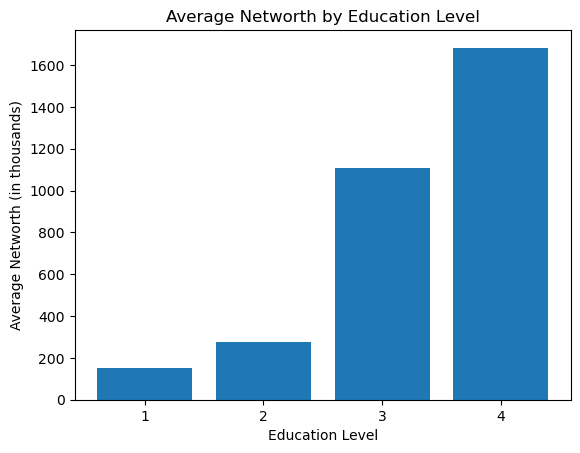

In [6]:
#making loop which considers each value in the 'educ' column 
for educ_level in df['educ'].unique():
#creates the variable avg_networth within the loop which takes all values in the column 'networth'
#for each equal value in the column 'educ' and computes the mean of these values
    avg_networth = df[df['educ'] == educ_level]['networth'].mean()
#stores the average networth for each education level in separate variables
    if educ_level == 1:
        avg_networth_educ1 = avg_networth
    elif educ_level == 2:
        avg_networth_educ2 = avg_networth
    elif educ_level == 3:
        avg_networth_educ3 = avg_networth
    else:
        avg_networth_educ4 = avg_networth

#creates a bar chart to visualize the average networth for each education level
import matplotlib.pyplot as plt
#creates a list of education levels
education_levels = ['1', '2', '3', '4']
#creates a list of average networths corresponding to each education level
average_networths = [avg_networth_educ1, avg_networth_educ2
, avg_networth_educ3, avg_networth_educ4]
#creates a bar chart with education levels on the x-axis and average networths on the
#y-axis
plt.bar(education_levels, average_networths)
#adds labels and title to the bar chart
plt.xlabel('Education Level')
plt.ylabel('Average Networth (in thousands)')
plt.title('Average Networth by Education Level')
#displays the bar chart
plt.show()

### Part 3 - Computing average networth by survey years and visualizing the data through a line plot

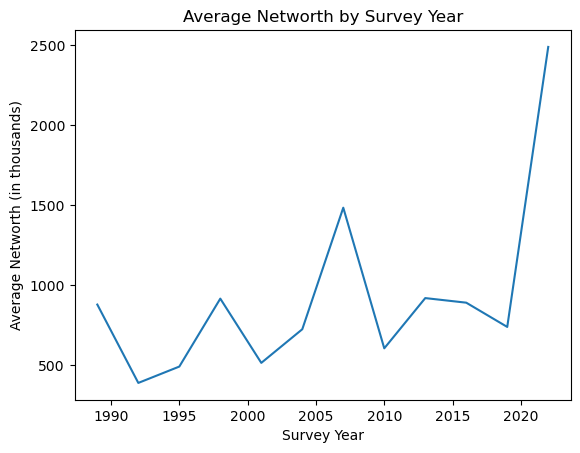

In [7]:
#creating lists to store average networth and corresponding years
networth_list = []
year_list = []
#using a loop to compute average networth by survey years
for survey_year in sorted(df['year'].unique()): 
#creating the variable avg_networth to compute the average networth for each year
    avg_networth_per_year = df[df['year'] == survey_year]['networth'].mean()
#appending the computed average networth and corresponding year to the lists
    networth_list.append(avg_networth_per_year)
    year_list.append(survey_year)
#making the line plot to visualize the average networth by survey years 
plt.plot(year_list, networth_list)
#adding labels and title
plt.xlabel('Survey Year')
plt.ylabel('Average Networth (in thousands)')
plt.title('Average Networth by Survey Year')
#displaying the line plot
plt.show()


### Task 4 - Combining the different analysis to see how net worth has evolved for those with and without college

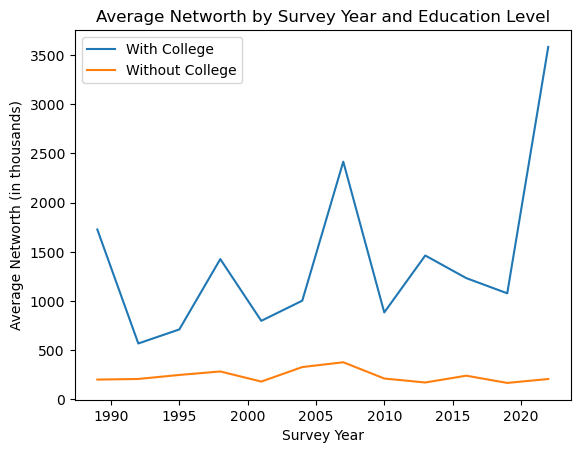

In [8]:
#creating lists to store average networth for those with and without college education and corresponding years
networth_college = []
networth_no_college = []
year_list = []
#using a loop to compute average networth by survey years for those with and without college education
for survey_year in sorted(df['year'].unique()):
#creating the variable avg_networth_college to compute the average networth for those with college education
    avg_networth_college = df[(df['year'] == survey_year) & (df['college'] == 1)]['networth'].mean()
#creating the variable avg_networth_no_college to compute the average networth for those without college education
    avg_networth_no_college = df[(df['year'] == survey_year) & (df['college'] == 0)]['networth'].mean()
#appending the computed average networths and corresponding year to the lists
    networth_college.append(avg_networth_college)
    networth_no_college.append(avg_networth_no_college)
    year_list.append(survey_year)
#making the line plot to visualize the average networth by survey years for those with and without college education
plt.plot(year_list, networth_college, label='With College')
plt.plot(year_list, networth_no_college, label='Without College')
#adding labels, title, and legend to the line plot
plt.xlabel('Survey Year')
plt.ylabel('Average Networth (in thousands)')
plt.title('Average Networth by Survey Year and Education Level')
plt.legend()
#displaying the line plot
plt.show()

***
# Data description

## Variables

| Variable         | Description |
|------------------|-------------|
| id               | Identifier  |
| year             | Survey year |
| age             | Age of reference person (household head) |
| educ            | Education of reference person (1 = no high school/GED, 2 = high school or GED, 3 = some college or Assoc. degree, 4 = Bachelors degree or higher)|
| networth        | Net worth in US dollars |

## Reference

- URL: https://www.federalreserve.gov/econres/scfindex.htm
- DOI Identifier: https://doi.org/10.17016/8799
- Creator: Board of Governors of the Federal Reserve Board
- Name: 2022 Survey of Consumer Finances
- Description:
    The Survey of Consumer Finances (SCF) is normally a triennial cross-sectional survey of U.S. families. The survey data include information on families' balance sheets, pensions, income, and demographic characteristics.
- Publisher: Board of Governors of the Federal Reserve System
- Publication Year: 2023 